In [8]:
import os
import logging
import warnings

# 1. Force environment variable BEFORE importing TF
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# 2. Block Python warnings
warnings.filterwarnings('ignore')

# 3. Disable loggers
logging.getLogger().setLevel(logging.CRITICAL)
logging.getLogger('tensorflow').setLevel(logging.CRITICAL)

print("Mute protocols engaged.")

Mute protocols engaged.


Loading datasets...
Dataset loaded, Text Vectorization started...


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_16           │ ?                      │   0 (unbuilt) │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L1 (Dense)                      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Training started...
Epoch 1/15
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 34s 26ms/step - accuracy: 0.8989 - loss: 0.5548 - val_accuracy: 0.9077 - val_loss: 0.5264
Epoch 2/15
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.9394 - loss: 0.2396 - val_accuracy: 0.8876 - val_loss: 0.6278
Epoch 3/15
1247/1247 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.9423 - loss: 0.2135 - val_accuracy: 0.8934 - val_loss: 0.6606
6786/6786 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - accuracy: 0.9077 - loss: 0.5264
Complete!
Final Evaluated Test Accuracy: 90.77%
Final Evaluated Test Loss:     0.5264
----------------------------------------------------------
Final Train Accuracy:          94.23%
Final Train Loss:              0.2135


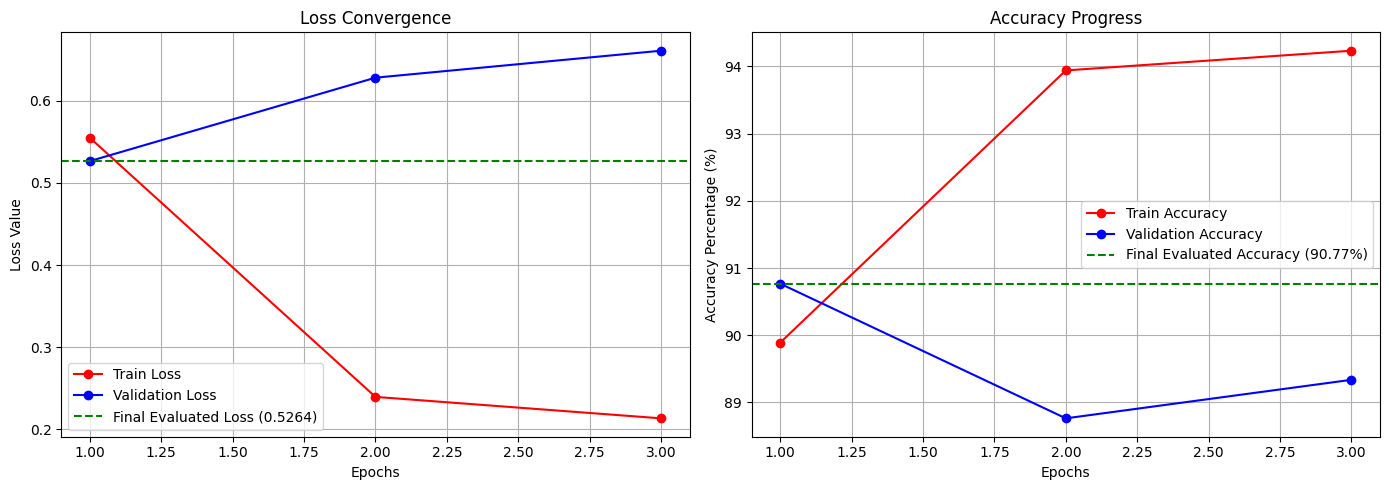

In [19]:
from datasets import load_dataset
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, TextVectorization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping # FIXED: Added missing import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATASET_NAME = "thesofakillers/jigsaw-toxic-comment-classification-challenge"

# DATASET LOADING AND VALUES EXTRACTION
print("Loading datasets...")
train_dataset = load_dataset(DATASET_NAME, split="train")
test_dataset  = load_dataset(DATASET_NAME, split="test")

df_train = train_dataset.to_pandas()
df_test = test_dataset.to_pandas()

FEATURE_COL = 'comment_text'
TARGET_COLS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Filtering out the unlabeled (-1) rows from the test set
df_test = df_test[(df_test[TARGET_COLS] != -1).all(axis=1)]

X_train = df_train[FEATURE_COL].fillna("").astype(str).values
X_test  = df_test[FEATURE_COL].fillna("").astype(str).values

# Using == 1 for true binary classification
Y_train = (df_train[TARGET_COLS] == 1).any(axis=1).astype(int).values
Y_test  = (df_test[TARGET_COLS] == 1).any(axis=1).astype(int).values



# Apply TF-IDF Text Vectorization
print("Dataset loaded, Text Vectorization started...")
MAX_WORDS = 3000
feature_vector = TextVectorization(max_tokens=MAX_WORDS, output_mode='tf_idf',ngrams=2)
feature_vector.adapt(X_train)


model = Sequential([
    feature_vector,
    Dense(32, activation='relu',kernel_regularizer=l2(0.005), name='L1'),
    Dropout(0.6, name='dropout_layer'),
    Dense(1, activation='sigmoid', name='Output')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Setup Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

print("Training started...")
history = model.fit(
    X_train, Y_train,
    epochs=15,
    batch_size=128,
    validation_data=(X_test, Y_test),
    callbacks=[early_stopping]
)

# Extract metrics from history
J_train = history.history['loss']
J_val = history.history['val_loss']
Accuracy_train = history.history['accuracy']
Accuracy_val = history.history['val_accuracy']

J_test, Accuracy_test = model.evaluate(X_test, Y_test)

print("Complete!")
print(f"Final Evaluated Test Accuracy: {Accuracy_test * 100:.2f}%")
print(f"Final Evaluated Test Loss:     {J_test:.4f}")
print("----------------------------------------------------------")
print(f"Final Train Accuracy:          {Accuracy_train[-1] * 100:.2f}%")
print(f"Final Train Loss:              {J_train[-1]:.4f}")

actual_epochs = len(J_train)
epochs_range = range(1, actual_epochs + 1)

plt.figure("Model Performance Evaluation", figsize=(14, 5))

# Loss Evaluation
plt.subplot(1, 2, 1)
plt.plot(epochs_range, J_train, label='Train Loss', color='red', marker='o')
plt.plot(epochs_range, J_val, label='Validation Loss', color='blue', marker='o')
plt.axhline(y=J_test, color='green', linestyle='--', label=f'Final Evaluated Loss ({J_test:.4f})')
plt.title('Loss Convergence')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

# Accuracy Evaluation
plt.subplot(1, 2, 2)
plt.plot(epochs_range, [acc * 100 for acc in Accuracy_train], label='Train Accuracy', color='red', marker='o')
plt.plot(epochs_range, [acc * 100 for acc in Accuracy_val], label='Validation Accuracy', color='blue', marker='o')
plt.axhline(y=Accuracy_test * 100, color='green', linestyle='--', label=f'Final Evaluated Accuracy ({Accuracy_test*100:.2f}%)')
plt.title('Accuracy Progress')
plt.xlabel('Epochs')
plt.ylabel('Accuracy Percentage (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
model.save('toxic_comment_model.keras')
from google.colab import files
files.download('toxic_comment_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>